In [1]:
%reload_kedro

[09/02/25 07:08:10] INFO     Resolved project path as:                                              ]8;id=550857;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=643731;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py#175\175]8;;\
                             C:\Users\nicolas.betancourt\Documents\GitHub\pytorch\serpientes-de-col                
                             ombia.                                                                                
                             To set a different path, run '%reload_kedro <project_root>'                           

[09/02/25 07:08:11] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=622176;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=362014;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro_telemetry\plugin.py#243\243]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[09/02/25 07:08:12] INFO     Kedro project serpientes_de_colombia                                   ]8;id=853201;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=867925;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py#141\141]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=493584;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=172708;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py#142\142]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=391082;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=78264;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\

In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [12]:
predictions=catalog.load('ResNet50_predictions')

[09/02/25 07:28:44] INFO     Loading data from ResNet50_predictions (CSVDataset)...             ]8;id=490428;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=417098;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\io\data_catalog.py#539\539]8;;\

In [8]:
label_encoder=catalog.load( 'label_encoder')

[09/02/25 07:09:38] INFO     Loading data from label_encoder (JSONDataset)...                   ]8;id=262839;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=662037;file://C:\Users\nicolas.betancourt\AppData\Local\anaconda3\envs\serpientes_env\lib\site-packages\kedro\io\data_catalog.py#539\539]8;;\

In [14]:
predictions.columns

Index(['path', 'label', 'prediction'], dtype='object')

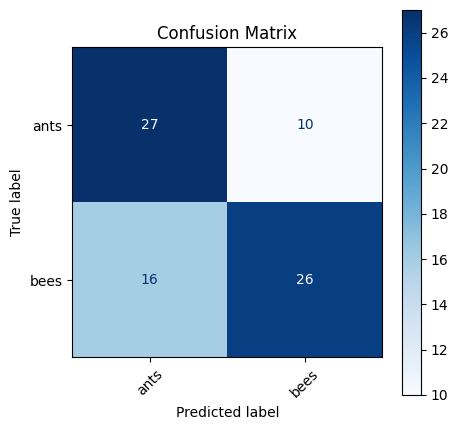

In [11]:
# Compute confusion matrix
cm = confusion_matrix(predictions['label'], predictions['prediction'])
%matplotlib inline
# Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.keys())
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title("Confusion Matrix")
plt.show()